Loading datasets...
All datasets loaded successfully.

Target grid:
Latitude : (180,)
Longitude: (360,)

Argo target:
<xarray.DataArray 'TEMP' (LEVEL: 23, LATITUDE: 180, LONGITUDE: 360)> Size: 6MB
[1490400 values with dtype=float32]
Coordinates:
  * LEVEL      (LEVEL) float32 92B 30.0 50.0 75.0 ... 1.5e+03 1.75e+03 2e+03
  * LATITUDE   (LATITUDE) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * LONGITUDE  (LONGITUDE) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Attributes:
    units:      degC
    title:      Argo Temperature
    long_name:  Argo Temperature

Target depths:
[  30.   50.   75.  100.  125.  150.  200.  250.  300.  400.  500.  600.
  700.  800.  900. 1000. 1100. 1200. 1300. 1400. 1500. 1750. 2000.]

Processing SST...
SST final shape: (180, 360)

Processing SSH...
SSH final shape: (180, 360)

Processing ERA5 wind...
U10 final shape: (180, 360)
V10 final shape: (180, 360)

================ SHAPE CHECK ================
SST : (180, 360)
SSH : (180, 360)
U10 : (180, 

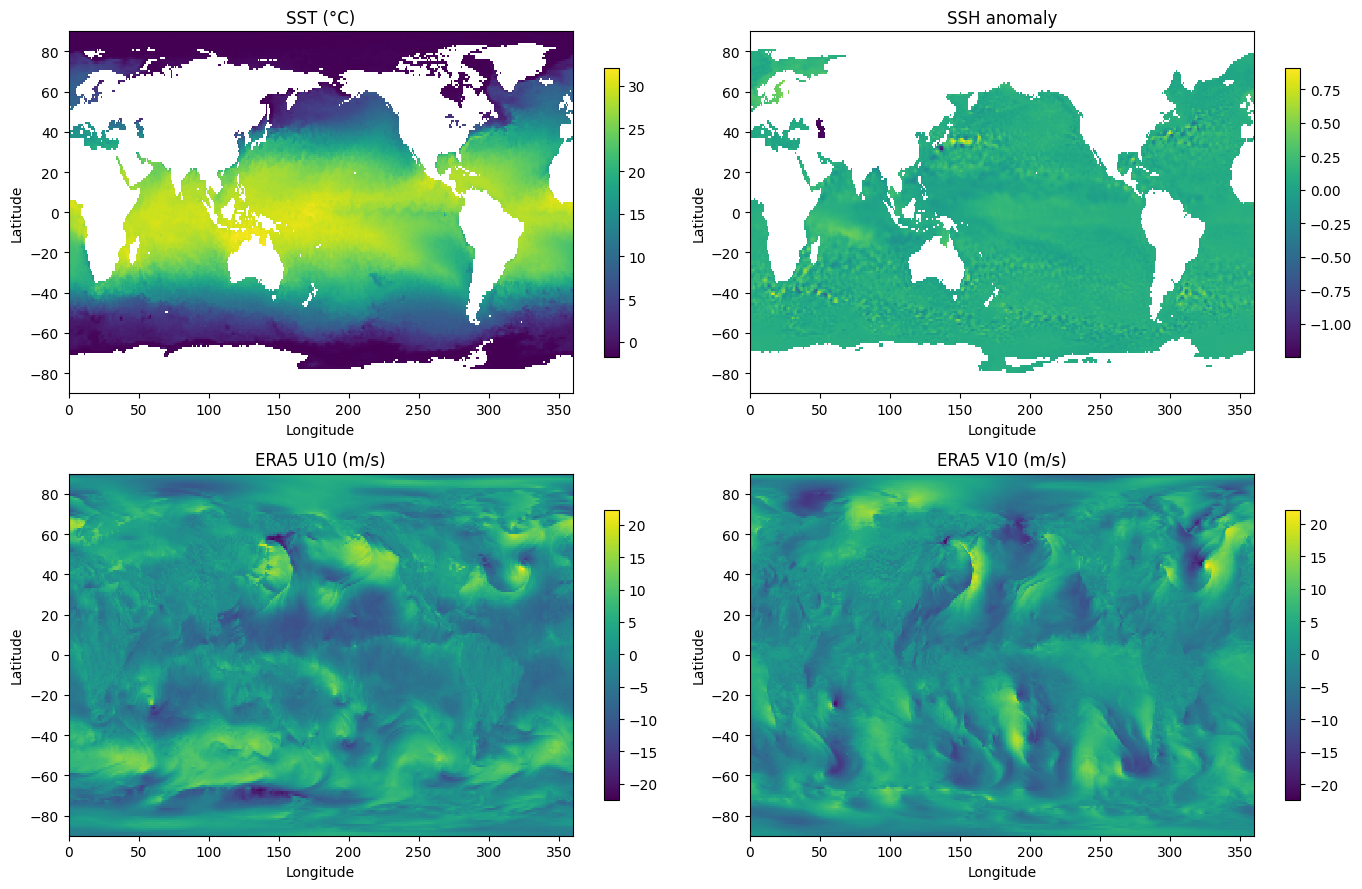

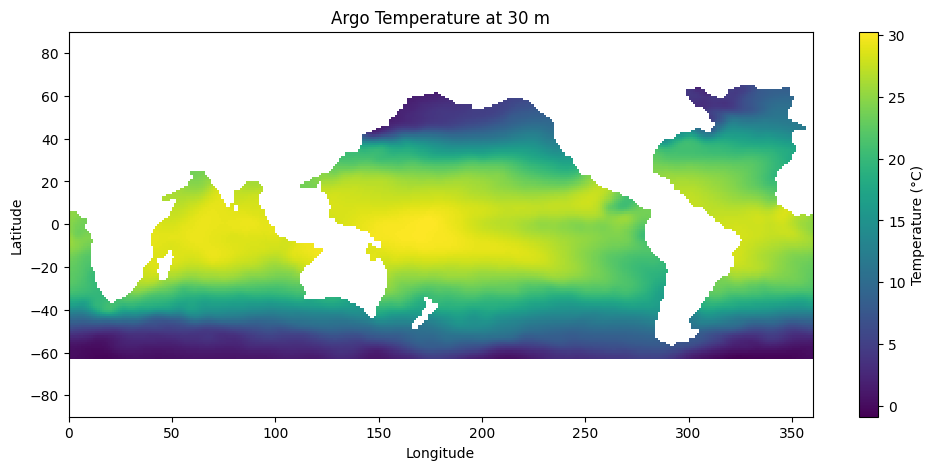


================ FINAL SINGLE-MONTH DATA ================
X shape: (180, 360, 4)
Y shape: (23, 180, 360)

Preprocessed files saved to:
/content/drive/MyDrive/SIH2026/Processed

DONE.


In [21]:
# ============================================================
# OCEAN SUBSURFACE TEMPERATURE RECONSTRUCTION
# PREPROCESSING PIPELINE
#
# Inputs:
#   1. OISST SST
#   2. Satellite SSH
#   3. ERA5 U10
#   4. ERA5 V10
#
# Target:
#   Argo subsurface temperature at 23 depths
#
# Final spatial resolution:
#   1° x 1°
#
# ============================================================


import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os


# ============================================================
# 1. FILE PATHS
# ============================================================

ARGO_PATH = "/content/drive/MyDrive/SIH2026/Dataset/ArgoData.nc"
SST_PATH  = "/content/drive/MyDrive/SIH2026/Dataset/OI-SST.nc"
SSH_PATH  = "/content/drive/MyDrive/SIH2026/Dataset/SSH.nc"
WIND_PATH = "/content/drive/MyDrive/SIH2026/Dataset/SurfaceWind_x_y.nc"


# ============================================================
# 2. LOAD DATASETS
# ============================================================

print("Loading datasets...")

argo = xr.open_dataset(ARGO_PATH)
sst  = xr.open_dataset(SST_PATH)
ssh  = xr.open_dataset(SSH_PATH)
wind = xr.open_dataset(WIND_PATH)

print("All datasets loaded successfully.")


# ============================================================
# 3. ARGO = REFERENCE GRID
# ============================================================
#
# Why?
#
# Argo is already on a regular 1° x 1° grid.
#
# Therefore every satellite/reanalysis variable will be
# transformed onto exactly the same latitude/longitude grid.
#
# This is important because the neural network requires every
# input channel to have identical spatial dimensions.
#
# ============================================================

target_lat = argo["LATITUDE"]
target_lon = argo["LONGITUDE"]

print("\nTarget grid:")
print("Latitude :", target_lat.shape)
print("Longitude:", target_lon.shape)


# ============================================================
# 4. SELECT THE 23 TARGET DEPTHS FROM ARGO
# ============================================================
#
# Argo contains 27 standard levels:
#
# 0, 5, 10, 20, 30, ... 2000 m
#
# Your model needs the 23 depths from 30 m to 2000 m.
#
# ============================================================

TARGET_DEPTHS = [
    30, 50, 75, 100, 125, 150,
    200, 250, 300, 400, 500, 600,
    700, 800, 900, 1000, 1100, 1200,
    1300, 1400, 1500, 1750, 2000
]

argo_target = argo["TEMP"].sel(
    LEVEL=TARGET_DEPTHS
)

print("\nArgo target:")
print(argo_target)

print("\nTarget depths:")
print(argo_target["LEVEL"].values)


# ============================================================
# 5. PROCESS SST
# ============================================================
#
# Original:
#   0.25° x 0.25°
#
# Target:
#   1° x 1°
#
# Why interpolate?
#
# ConvLSTM cannot directly combine a 720 x 1440 SST grid
# with a 180 x 360 Argo grid.
#
# We therefore interpolate SST onto the Argo grid.
#
# ============================================================

print("\nProcessing SST...")

sst_raw = sst["sst"].isel(
    time=0,
    zlev=0
)

sst_1deg = sst_raw.interp(
    lat=target_lat,
    lon=target_lon,
    method="linear"
)

print("SST final shape:", sst_1deg.shape)


# ============================================================
# 6. PROCESS SSH
# ============================================================
#
# SSH longitude is approximately:
#
#   -180° ... +180°
#
# Argo longitude is:
#
#   0° ... 360°
#
# We convert SSH longitude into the same 0-360 convention.
#
# ============================================================

print("\nProcessing SSH...")

ssh_raw = ssh["sla"].isel(time=0)

# Convert longitude:
# -180...180  -->  0...360

ssh_raw = ssh_raw.assign_coords(
    longitude=ssh_raw["longitude"] % 360
)

# Sort longitude after conversion

ssh_raw = ssh_raw.sortby("longitude")


# Interpolate SSH to Argo 1° grid

ssh_1deg = ssh_raw.interp(
    latitude=target_lat,
    longitude=target_lon,
    method="linear"
)

print("SSH final shape:", ssh_1deg.shape)


# ============================================================
# 7. PROCESS ERA5 WIND
# ============================================================
#
# ERA5 latitude is descending:
#
# 90 ... -90
#
# Argo latitude is ascending:
#
# -89.5 ... 89.5
#
# We first sort latitude in ascending order.
#
# Then interpolate U10 and V10 independently.
#
# ============================================================

print("\nProcessing ERA5 wind...")

u10_raw = wind["u10"].isel(
    valid_time=0
)

v10_raw = wind["v10"].isel(
    valid_time=0
)


# Sort latitude ascending

u10_raw = u10_raw.sortby("latitude")
v10_raw = v10_raw.sortby("latitude")


# Interpolate to 1° Argo grid

u10_1deg = u10_raw.interp(
    latitude=target_lat,
    longitude=target_lon,
    method="linear"
)

v10_1deg = v10_raw.interp(
    latitude=target_lat,
    longitude=target_lon,
    method="linear"
)

print("U10 final shape:", u10_1deg.shape)
print("V10 final shape:", v10_1deg.shape)


# ============================================================
# 8. CHECK SHAPES
# ============================================================
#
# Every input must now have:
#
#       180 x 360
#
# And target:
#
#       23 x 180 x 360
#
# ============================================================

print("\n================ SHAPE CHECK ================")

print("SST :", sst_1deg.shape)
print("SSH :", ssh_1deg.shape)
print("U10 :", u10_1deg.shape)
print("V10 :", v10_1deg.shape)
print("ARGO:", argo_target.shape)


# ============================================================
# 9. CONVERT EVERYTHING TO NUMPY
# ============================================================
#
# TensorFlow/Keras works naturally with NumPy arrays.
#
# ============================================================

sst_np = sst_1deg.values.astype(np.float32)
ssh_np = ssh_1deg.values.astype(np.float32)
u10_np = u10_1deg.values.astype(np.float32)
v10_np = v10_1deg.values.astype(np.float32)

y_np = argo_target.values.astype(np.float32)


# ============================================================
# 10. CHECK NaN VALUES
# ============================================================
#
# Ocean datasets naturally contain missing values.
#
# DO NOT replace them blindly with zero.
#
# Zero temperature is a physically meaningful value and would
# introduce fake observations.
#
# We first inspect how much missing data exists.
#
# ============================================================

print("\n================ NaN CHECK ================")

print(
    "SST NaN:",
    np.isnan(sst_np).sum(),
    f"({np.isnan(sst_np).mean()*100:.2f}%)"
)

print(
    "SSH NaN:",
    np.isnan(ssh_np).sum(),
    f"({np.isnan(ssh_np).mean()*100:.2f}%)"
)

print(
    "U10 NaN:",
    np.isnan(u10_np).sum(),
    f"({np.isnan(u10_np).mean()*100:.2f}%)"
)

print(
    "V10 NaN:",
    np.isnan(v10_np).sum(),
    f"({np.isnan(v10_np).mean()*100:.2f}%)"
)

print(
    "ARGO NaN:",
    np.isnan(y_np).sum(),
    f"({np.isnan(y_np).mean()*100:.2f}%)"
)


# ============================================================
# 11. STATISTICS
# ============================================================
#
# We inspect min/max/mean/std.
#
# This helps detect:
#   - incorrect units
#   - corrupted values
#   - bad interpolation
#   - unrealistic ranges
#
# ============================================================

def print_stats(name, data):

    valid = data[np.isfinite(data)]

    print(f"\n{name}")
    print("--------------------------------")
    print("Min :", np.min(valid))
    print("Max :", np.max(valid))
    print("Mean:", np.mean(valid))
    print("Std :", np.std(valid))


print_stats("SST", sst_np)
print_stats("SSH", ssh_np)
print_stats("U10", u10_np)
print_stats("V10", v10_np)
print_stats("ARGO TEMP", y_np)


# ============================================================
# 12. VISUALIZE THE PREPROCESSED INPUTS
# ============================================================
#
# Visualization is extremely important.
#
# Before training a deep-learning model, we should verify that
# the spatial fields look physically reasonable.
#
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9)
)

plots = [
    (sst_np, "SST (°C)"),
    (ssh_np, "SSH anomaly"),
    (u10_np, "ERA5 U10 (m/s)"),
    (v10_np, "ERA5 V10 (m/s)")
]

for ax, (data, title) in zip(axes.flat, plots):

    im = ax.pcolormesh(
        target_lon,
        target_lat,
        data,
        shading="auto"
    )

    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.colorbar(
        im,
        ax=ax,
        shrink=0.8
    )

plt.tight_layout()
plt.show()


# ============================================================
# 13. VISUALIZE ONE ARGO DEPTH
# ============================================================
#
# We inspect the 30 m temperature field.
#
# ============================================================

depth_index = 0

plt.figure(figsize=(12, 5))

plt.pcolormesh(
    target_lon,
    target_lat,
    y_np[depth_index],
    shading="auto"
)

plt.colorbar(label="Temperature (°C)")

plt.title(
    f"Argo Temperature at {TARGET_DEPTHS[depth_index]} m"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


# ============================================================
# 14. CREATE INPUT TENSOR
# ============================================================
#
# Current data contains four input variables:
#
#   Channel 0 = SST
#   Channel 1 = SSH
#   Channel 2 = U10
#   Channel 3 = V10
#
# Therefore:
#
# X shape = (180, 360, 4)
#
# ============================================================

X = np.stack(
    [
        sst_np,
        ssh_np,
        u10_np,
        v10_np
    ],
    axis=-1
)

print("\n================ FINAL SINGLE-MONTH DATA ================")

print("X shape:", X.shape)
print("Y shape:", y_np.shape)


# ============================================================
# 15. SAVE PREPROCESSED SINGLE-MONTH DATA
# ============================================================
#
# Saving avoids repeating interpolation every time we run
# the notebook.
#
# ============================================================

OUTPUT_DIR = "/content/drive/MyDrive/SIH2026/Processed"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


np.save(
    os.path.join(OUTPUT_DIR, "X_Jan2020.npy"),
    X
)

np.save(
    os.path.join(OUTPUT_DIR, "Y_Jan2020.npy"),
    y_np
)

np.save(
    os.path.join(OUTPUT_DIR, "target_depths.npy"),
    np.array(TARGET_DEPTHS)
)

np.save(
    os.path.join(OUTPUT_DIR, "latitude.npy"),
    target_lat.values
)

np.save(
    os.path.join(OUTPUT_DIR, "longitude.npy"),
    target_lon.values
)


print("\nPreprocessed files saved to:")
print(OUTPUT_DIR)

print("\nDONE.")

In [18]:
#  Argo output


target_lat = argo["LATITUDE"]

target_lon = argo["LONGITUDE"]

print("Target latitude:", target_lat.shape)
print("Target longitude:", target_lon.shape)

Target latitude: (180,)
Target longitude: (360,)


In [ ]:
#   Process the SSH
# ssh is -180 to + 180 and argo uses  0.5 to 359.5  so convert the ssh 0 to 360